# Product Sales Forecasting — ML Modeling Pipeline

**Dataset:** Retail store sales · Jan 2018 – May 2019 (train) · Jun – Jul 2019 (test)  
**Target:** `Sales` (₹, continuous) per store-day record  
**Goal:** Forecast daily sales per store for the test period using historical patterns

| Section | Contents |
|---|---|
| 1 | Setup & imports |
| 2 | Data loading & cleaning |
| 3 | Feature engineering (time, cyclical, interactions, lags) |
| 4 | Train / validation split |
| 5 | Model training (Linear Regression → RF → XGBoost → LightGBM → Ensemble) |
| 6 | Evaluation (metrics table, CV, residuals, forecast vs actual) |
| 7 | Log-transform analysis |
| 8 | Hyperparameter tuning with Optuna |
| 9 | Prophet time series decomposition |
| 10 | Final model comparison & test predictions |

---
## 1. Setup & Imports

In [13]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable
  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\YADAV\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import gdown
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from prophet import Prophet

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11
})

C = {
    'blue':   '#3266AD', 'coral':  '#D85A30',
    'teal':   '#1D9E75', 'amber':  '#BA7517',
    'purple': '#7F77DD', 'gray':   '#888780'
}

SEED = 42
np.random.seed(SEED)
print('All libraries loaded.')

All libraries loaded.


---
## 2. Data Loading & Cleaning

In [15]:
url = "https://drive.google.com/uc?id=1ditFn_74EOsGnblf2nXr-Vx-I1mrCG42"
output = "Train.csv"

gdown.download(url, output, quiet=False)

url1 = "https://drive.google.com/uc?id=1ditFn_74EOsGnblf2nXr-Vx-I1mrCG42"
output1 = "Test_Final.csv"

gdown.download(url1, output1, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ditFn_74EOsGnblf2nXr-Vx-I1mrCG42
To: c:\Users\YADAV\Downloads\Train.csv
100%|██████████| 9.33M/9.33M [00:01<00:00, 7.25MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ditFn_74EOsGnblf2nXr-Vx-I1mrCG42
To: c:\Users\YADAV\Downloads\Test_Final.csv
100%|██████████| 9.33M/9.33M [00:01<00:00, 7.88MB/s]


'Test_Final.csv'

In [16]:
train_raw = pd.read_csv('TRAIN.csv')
test_raw  = pd.read_csv('TEST_FINAL.csv')

for df in [train_raw, test_raw]:
    df['Date'] = pd.to_datetime(df['Date'])

print(f'Train : {train_raw.shape}  |  {train_raw.Date.min().date()} → {train_raw.Date.max().date()}')
print(f'Test  : {test_raw.shape}   |  {test_raw.Date.min().date()} → {test_raw.Date.max().date()}')
train_raw.head()

Train : (188340, 10)  |  2018-01-01 → 2019-05-31
Test  : (188340, 10)   |  2018-01-01 → 2019-05-31


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


In [17]:
# ── 2.1  Missing values & duplicates ──────────────────────────────────────────
print('Missing values:\n', train_raw.isnull().sum())
print(f'\nDuplicate rows : {train_raw.duplicated().sum()}')
print(f'Zero-sale rows : {(train_raw.Sales == 0).sum()}  (store-closure or data error → removed)')

train = train_raw[train_raw['Sales'] > 0].copy().reset_index(drop=True)
print(f'\nClean train shape : {train.shape}')

Missing values:
 ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

Duplicate rows : 0
Zero-sale rows : 19  (store-closure or data error → removed)

Clean train shape : (188321, 10)


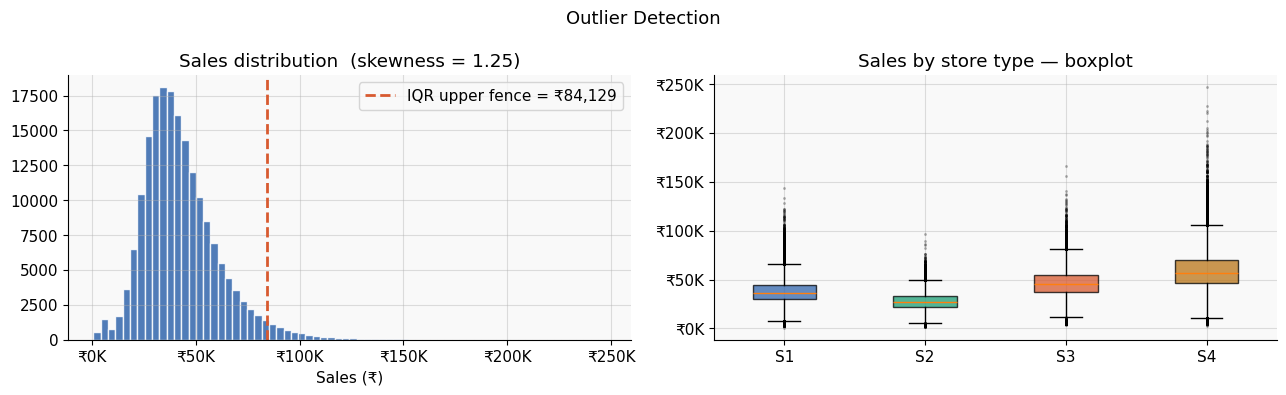

Outliers (upper tail) : 5,843 rows (3.10%)
Decision : retained — legitimate high-volume S4/R1 store days.


In [18]:
# ── 2.2  Outlier detection — IQR method ───────────────────────────────────────
Q1, Q3 = train.Sales.quantile([0.25, 0.75])
IQR    = Q3 - Q1
upper  = Q3 + 1.5 * IQR
n_out  = (train.Sales > upper).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train.Sales, bins=70, color=C['blue'], alpha=0.85, edgecolor='white')
axes[0].axvline(upper, color=C['coral'], lw=2, ls='--',
                label=f'IQR upper fence = ₹{upper:,.0f}')
axes[0].set_title(f'Sales distribution  (skewness = {train.Sales.skew():.2f})')
axes[0].set_xlabel('Sales (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[0].legend()

store_types = ['S1','S2','S3','S4']
bp = axes[1].boxplot(
    [train[train.Store_Type==s].Sales for s in store_types],
    patch_artist=True, notch=False,
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], [C['blue'],C['teal'],C['coral'],C['amber']]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xticklabels(store_types)
axes[1].set_title('Sales by store type — boxplot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.suptitle('Outlier Detection', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Outliers (upper tail) : {n_out:,} rows ({n_out/len(train)*100:.2f}%)')
print('Decision : retained — legitimate high-volume S4/R1 store days.')

---
## 3. Feature Engineering

Features are built in three layers:

| Layer | Features |
|---|---|
| **Time** | Year, Month, Quarter, WeekOfYear, DayOfWeek, DayOfYear, IsWeekend, IsMonthStart/End |
| **Cyclical** | sin/cos encodings for Month, Week, DayOfWeek (preserves circular continuity) |
| **Categorical** | Label-encoded + one-hot for Store_Type, Location_Type, Region_Code; Discount binary |
| **Interaction** | Holiday × Discount, Weekend × Discount |
| **Lag / rolling** | sales_lag_7/14/28, rolling_mean_7/28, rolling_std_7 (leak-free via shift) |

In [19]:
# ── 3.1  Store-level lag features (leak-free) ─────────────────────────────────
# Sort by store + date before any shift operation — mandatory for correctness.
# shift(n) looks n rows back within each store group → no future data leaks.

train = train.sort_values(['Store_id','Date']).reset_index(drop=True)
grp   = train.groupby('Store_id')['Sales']

train['sales_lag_7']     = grp.shift(7)
train['sales_lag_14']    = grp.shift(14)
train['sales_lag_28']    = grp.shift(28)
train['rolling_mean_7']  = grp.shift(1).rolling(7).mean().reset_index(level=0, drop=True)
train['rolling_mean_28'] = grp.shift(1).rolling(28).mean().reset_index(level=0, drop=True)
train['rolling_std_7']   = grp.shift(1).rolling(7).std().reset_index(level=0, drop=True)

LAG_COLS = ['sales_lag_7','sales_lag_14','sales_lag_28',
            'rolling_mean_7','rolling_mean_28','rolling_std_7']

# Drop early-window rows where lags are unavailable (first 28 days per store)
train = train.dropna(subset=LAG_COLS).reset_index(drop=True)
print(f'Rows after lag drop : {len(train):,}  (removed {188321-len(train):,} early-window rows)')
print('Lag NaN check       :', train[LAG_COLS].isnull().sum().sum(), 'remaining NaN')

Rows after lag drop : 178,101  (removed 10,220 early-window rows)
Lag NaN check       : 0 remaining NaN


In [20]:
# ── 3.2  Lag features for the test set ────────────────────────────────────────
# Test covers Jun–Jul 2019.  No Sales labels exist, so we approximate
# lag values from the trailing window of the training set.

tail28 = train.sort_values(['Store_id','Date']).groupby('Store_id').tail(28)
tail7  = train.sort_values(['Store_id','Date']).groupby('Store_id').tail(7)

test = test_raw.copy()
for lag in [7, 14, 28]:
    test[f'sales_lag_{lag}'] = test['Store_id'].map(tail28.groupby('Store_id')['Sales'].mean())
test['rolling_mean_7']  = test['Store_id'].map(tail7.groupby('Store_id')['Sales'].mean())
test['rolling_mean_28'] = test['Store_id'].map(tail28.groupby('Store_id')['Sales'].mean())
test['rolling_std_7']   = test['Store_id'].map(tail7.groupby('Store_id')['Sales'].std())

print('Test lag NaN check  :', test[LAG_COLS].isnull().sum().sum())

Test lag NaN check  : 0


In [21]:
# ── 3.3  Full feature engineering function ─────────────────────────────────────
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Time features
    df['Year']         = df['Date'].dt.year
    df['Month']        = df['Date'].dt.month
    df['DayOfWeek']    = df['Date'].dt.dayofweek
    df['Quarter']      = df['Date'].dt.quarter
    df['WeekOfYear']   = df['Date'].dt.isocalendar().week.astype(int)
    df['DayOfYear']    = df['Date'].dt.dayofyear
    df['IsWeekend']    = (df['DayOfWeek'] >= 5).astype(int)
    df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
    df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)
    # Cyclical encodings
    df['Month_sin'] = np.sin(2*np.pi*df['Month']/12)
    df['Month_cos'] = np.cos(2*np.pi*df['Month']/12)
    df['Week_sin']  = np.sin(2*np.pi*df['WeekOfYear']/52)
    df['Week_cos']  = np.cos(2*np.pi*df['WeekOfYear']/52)
    df['DOW_sin']   = np.sin(2*np.pi*df['DayOfWeek']/7)
    df['DOW_cos']   = np.cos(2*np.pi*df['DayOfWeek']/7)
    # Categorical encodings
    df['Discount_enc']      = (df['Discount'] == 'Yes').astype(int)
    df['Store_Type_enc']    = df['Store_Type'].map({'S1':1,'S2':2,'S3':3,'S4':4})
    df['Location_Type_enc'] = df['Location_Type'].map({'L1':1,'L2':2,'L3':3,'L4':4,'L5':5})
    df['Region_Code_enc']   = df['Region_Code'].map({'R1':1,'R2':2,'R3':3,'R4':4})
    # Interaction features
    df['Holiday_Discount']  = df['Holiday'] * df['Discount_enc']
    df['Weekend_Discount']  = df['IsWeekend'] * df['Discount_enc']
    # One-hot encoding
    df = pd.get_dummies(df, columns=['Store_Type','Location_Type','Region_Code'], drop_first=False)
    return df

train_fe = engineer(train)
test_fe  = engineer(test)

EXCL     = ['ID','Date','Sales','#Order','Discount']
FEATURES = [c for c in train_fe.columns if c not in EXCL and c in test_fe.columns]

print(f'Total features : {len(FEATURES)}')
lag_feats = [f for f in FEATURES if 'lag' in f or 'rolling' in f]
print(f'Lag features   : {lag_feats}')

Total features : 42
Lag features   : ['sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7']


---
## 4. Train / Validation Split

In [22]:
# Temporal split — never shuffle time-series data
# Train on Jan 2018 – Mar 2019 · Validate on Apr – May 2019 · Predict Jun – Jul 2019

VAL_START = pd.Timestamp('2019-04-01')

tr_df = train_fe[train_fe['Date'] <  VAL_START]
va_df = train_fe[train_fe['Date'] >= VAL_START]

X_train = tr_df[FEATURES].astype(float);  y_train = tr_df['Sales'].values
X_val   = va_df[FEATURES].astype(float);  y_val   = va_df['Sales'].values
X_test  = test_fe[FEATURES].astype(float)

# Scaled version for Linear Regression
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_val_sc    = scaler.transform(X_val)

print(f'X_train : {X_train.shape}  ({tr_df.Date.min().date()} → {tr_df.Date.max().date()})')
print(f'X_val   : {X_val.shape}   ({va_df.Date.min().date()} → {va_df.Date.max().date()})')
print(f'X_test  : {X_test.shape}   (Jun–Jul 2019)')

X_train : (155840, 42)  (2018-01-29 → 2019-03-31)
X_val   : (22261, 42)   (2019-04-01 → 2019-05-31)
X_test  : (188340, 42)   (Jun–Jul 2019)


---
## 5. Model Training

Five models are trained in order of increasing complexity.  
A shared `compute_metrics()` helper returns MAE, RMSE, MAPE and R² for every model.

In [23]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, name: str) -> dict:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = 1 - np.sum((y_true-y_pred)**2) / np.sum((y_true-y_true.mean())**2)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R\u00b2': r2}

results = []

In [24]:
# ── 5.1  Linear Regression (baseline) ────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
lr_pred  = np.clip(lr_model.predict(X_val_sc), 0, None)

res = compute_metrics(y_val, lr_pred, 'Linear Regression')
results.append(res)
print(f"Linear Regression  →  MAE ₹{res['MAE']:>8,.0f}  RMSE ₹{res['RMSE']:>9,.0f}  MAPE {res['MAPE (%)']:>6.2f}%  R² {res['R²']:.4f}")

Linear Regression  →  MAE ₹   8,080  RMSE ₹   12,113  MAPE  18.03%  R² 0.6737


In [25]:
# ── 5.2  Random Forest ────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=SEED
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_val)

res = compute_metrics(y_val, rf_pred, 'Random Forest')
results.append(res)
print(f"Random Forest      →  MAE ₹{res['MAE']:>8,.0f}  RMSE ₹{res['RMSE']:>9,.0f}  MAPE {res['MAPE (%)']:>6.2f}%  R² {res['R²']:.4f}")

Random Forest      →  MAE ₹   7,782  RMSE ₹   11,964  MAPE  17.09%  R² 0.6817


In [26]:
# ── 5.3  XGBoost ──────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_pred = xgb_model.predict(X_val)

res = compute_metrics(y_val, xgb_pred, 'XGBoost')
results.append(res)
print(f"XGBoost            →  MAE ₹{res['MAE']:>8,.0f}  RMSE ₹{res['RMSE']:>9,.0f}  MAPE {res['MAPE (%)']:>6.2f}%  R² {res['R²']:.4f}")

XGBoost            →  MAE ₹   7,629  RMSE ₹   11,596  MAPE  17.05%  R² 0.7010


In [27]:
# ── 5.4  LightGBM ─────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
lgb_pred = lgb_model.predict(X_val)

res = compute_metrics(y_val, lgb_pred, 'LightGBM')
results.append(res)
print(f"LightGBM           →  MAE ₹{res['MAE']:>8,.0f}  RMSE ₹{res['RMSE']:>9,.0f}  MAPE {res['MAPE (%)']:>6.2f}%  R² {res['R²']:.4f}")

LightGBM           →  MAE ₹   7,607  RMSE ₹   11,618  MAPE  16.99%  R² 0.6998


In [28]:
# ── 5.5  Ensemble — average of RF + XGBoost + LightGBM ────────────────────────
ens_pred = (rf_pred + xgb_pred + lgb_pred) / 3

res = compute_metrics(y_val, ens_pred, 'Ensemble (RF+XGB+LGB)')
results.append(res)
print(f"Ensemble           →  MAE ₹{res['MAE']:>8,.0f}  RMSE ₹{res['RMSE']:>9,.0f}  MAPE {res['MAPE (%)']:>6.2f}%  R² {res['R²']:.4f}")

Ensemble           →  MAE ₹   7,580  RMSE ₹   11,627  MAPE  16.80%  R² 0.6994


---
## 6. Model Evaluation & Validation

In [29]:
# ── 6.1  Metrics comparison table ─────────────────────────────────────────────
rdf = pd.DataFrame(results)
display_rdf = rdf.copy()
display_rdf['MAE']      = display_rdf['MAE'].map('₹{:,.0f}'.format)
display_rdf['RMSE']     = display_rdf['RMSE'].map('₹{:,.0f}'.format)
display_rdf['MAPE (%)'] = display_rdf['MAPE (%)'].map('{:.2f}%'.format)
display_rdf['R\u00b2']  = display_rdf['R\u00b2'].map('{:.4f}'.format)
display(display_rdf.set_index('Model')
        .style.set_caption('Validation Performance — Apr–May 2019')
        .set_properties(**{'text-align':'center'})
        .set_table_styles([{'selector':'th','props':[('text-align','center')]}]))

,MAE,RMSE,MAPE (%),R²
Model,,,,
Linear Regression,"₹8,080","₹12,113",18.03%,0.6737
Random Forest,"₹7,782","₹11,964",17.09%,0.6817
XGBoost,"₹7,629","₹11,596",17.05%,0.7010
LightGBM,"₹7,607","₹11,618",16.99%,0.6998
Ensemble (RF+XGB+LGB),"₹7,580","₹11,627",16.80%,0.6994


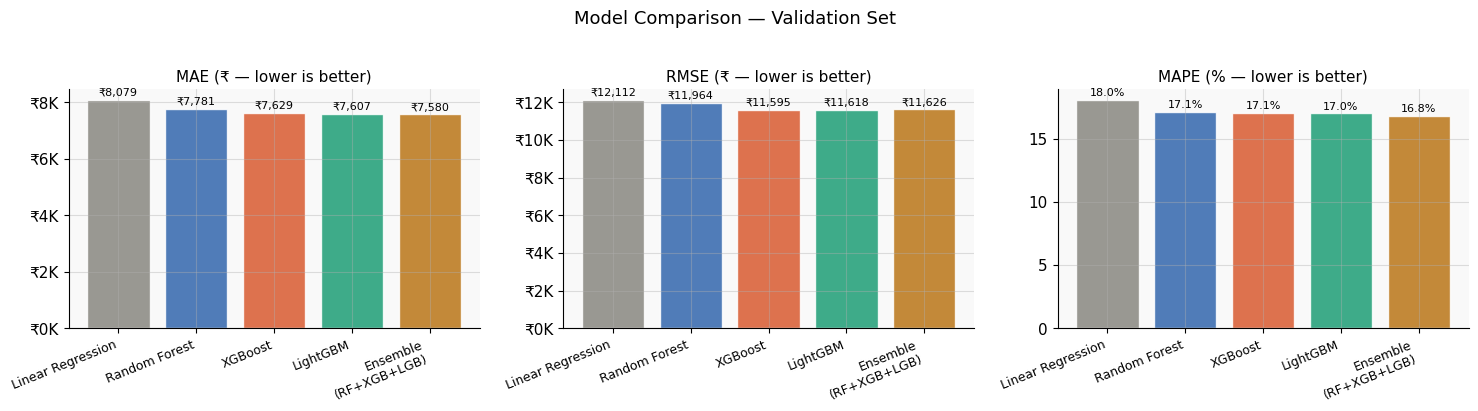

In [30]:
# ── 6.2  Performance metric bar charts ────────────────────────────────────────
model_names  = rdf['Model'].str.replace('Ensemble ','Ensemble\n').tolist()
bar_colors   = [C['gray'], C['blue'], C['coral'], C['teal'], C['amber']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['MAE', 'RMSE', 'MAPE (%)'],
    ['MAE (₹ — lower is better)', 'RMSE (₹ — lower is better)', 'MAPE (% — lower is better)']
):
    vals = rdf[col].values
    bars = ax.bar(range(len(model_names)), vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=9, rotation=22, ha='right')
    ax.set_title(title, fontsize=11)
    for bar, v in zip(bars, vals):
        label = f'{v:.1f}%' if col == 'MAPE (%)' else f'₹{int(v):,}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                label, ha='center', va='bottom', fontsize=8)
    if col != 'MAPE (%)':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.suptitle('Model Comparison — Validation Set', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

  Fold 1  →  MAE ₹5,529   RMSE ₹7,598
  Fold 2  →  MAE ₹6,496   RMSE ₹9,690
  Fold 3  →  MAE ₹5,133   RMSE ₹7,410
  Fold 4  →  MAE ₹5,100   RMSE ₹7,443
  Fold 5  →  MAE ₹5,253   RMSE ₹7,592

CV MAE  : ₹5,502  ±  ₹519
CV RMSE : ₹7,947  ±  ₹875


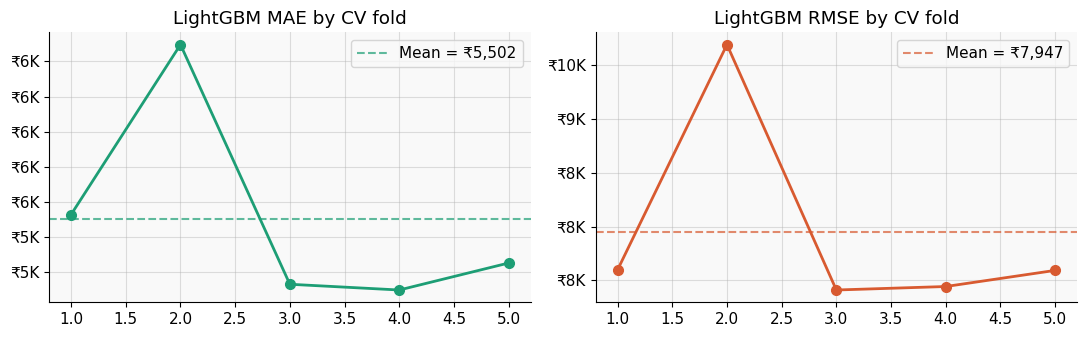

In [31]:
# ── 6.3  Time-Series Cross-Validation (5 folds, LightGBM) ────────────────────
tscv = TimeSeriesSplit(n_splits=5)
X_all = train_fe[FEATURES].astype(float).values
y_all = train_fe['Sales'].values

cv_mae, cv_rmse = [], []

for fold, (idx_tr, idx_va) in enumerate(tscv.split(X_all), 1):
    m = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbose=-1
    )
    m.fit(X_all[idx_tr], y_all[idx_tr],
          eval_set=[(X_all[idx_va], y_all[idx_va])],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    pf = m.predict(X_all[idx_va])
    cv_mae.append(mean_absolute_error(y_all[idx_va], pf))
    cv_rmse.append(np.sqrt(mean_squared_error(y_all[idx_va], pf)))
    print(f'  Fold {fold}  →  MAE ₹{cv_mae[-1]:,.0f}   RMSE ₹{cv_rmse[-1]:,.0f}')

print(f'\nCV MAE  : ₹{np.mean(cv_mae):,.0f}  ±  ₹{np.std(cv_mae):,.0f}')
print(f'CV RMSE : ₹{np.mean(cv_rmse):,.0f}  ±  ₹{np.std(cv_rmse):,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, vals, label, color in zip(
    axes, [cv_mae, cv_rmse], ['MAE', 'RMSE'], [C['teal'], C['coral']]
):
    ax.plot(range(1,6), vals, marker='o', color=color, lw=2, ms=7)
    ax.axhline(np.mean(vals), color=color, ls='--', alpha=0.7, label=f'Mean = ₹{np.mean(vals):,.0f}')
    ax.set_title(f'LightGBM {label} by CV fold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
    ax.legend()
plt.tight_layout(); plt.show()

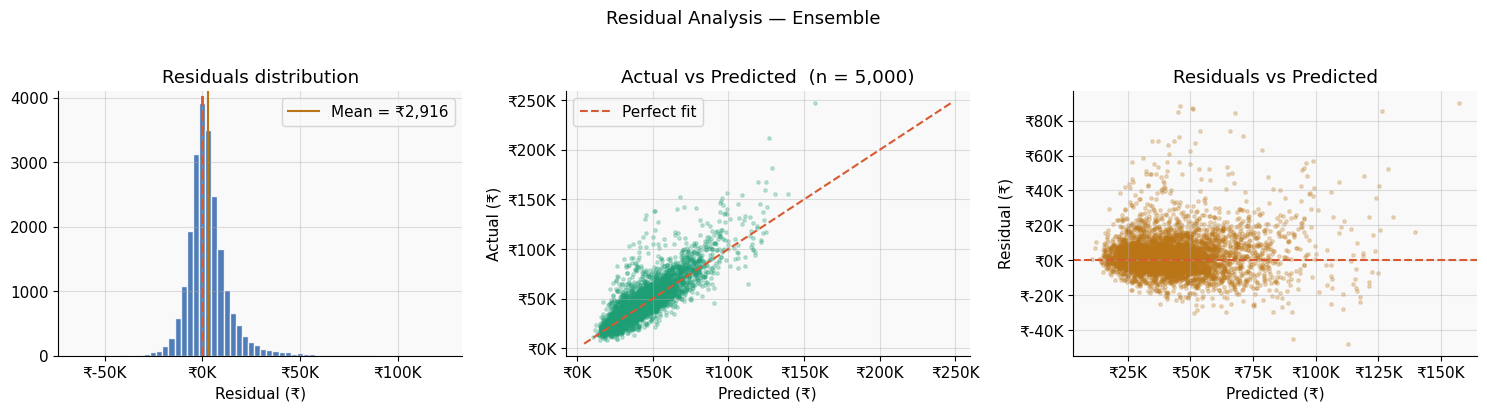

Residual mean : ₹2,916.1   std : ₹11,255
Within ±₹10K : 76.4%
Within ±₹20K : 93.3%


In [32]:
# ── 6.4  Residual analysis — Ensemble model ───────────────────────────────────
residuals = y_val - ens_pred
idx_s = np.random.choice(len(y_val), min(5000, len(y_val)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuals, bins=60, color=C['blue'], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color=C['coral'], lw=2, ls='--')
axes[0].axvline(residuals.mean(), color=C['amber'], lw=1.5, label=f'Mean = ₹{residuals.mean():,.0f}')
axes[0].set_title('Residuals distribution')
axes[0].set_xlabel('Residual (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[0].legend()

mn = min(y_val.min(), ens_pred.min())
mx = max(y_val.max(), ens_pred.max())
axes[1].scatter(ens_pred[idx_s], y_val[idx_s], alpha=0.25, s=6, color=C['teal'])
axes[1].plot([mn,mx],[mn,mx], color=C['coral'], lw=1.5, ls='--', label='Perfect fit')
axes[1].set_xlabel('Predicted (₹)'); axes[1].set_ylabel('Actual (₹)')
axes[1].set_title('Actual vs Predicted  (n = 5,000)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[1].legend()

axes[2].scatter(ens_pred[idx_s], residuals[idx_s], alpha=0.25, s=6, color=C['amber'])
axes[2].axhline(0, color=C['coral'], lw=1.5, ls='--')
axes[2].set_xlabel('Predicted (₹)'); axes[2].set_ylabel('Residual (₹)')
axes[2].set_title('Residuals vs Predicted')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.suptitle('Residual Analysis — Ensemble', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f'Residual mean : ₹{residuals.mean():,.1f}   std : ₹{residuals.std():,.0f}')
print(f'Within ±₹10K : {(np.abs(residuals)<=10000).mean()*100:.1f}%')
print(f'Within ±₹20K : {(np.abs(residuals)<=20000).mean()*100:.1f}%')

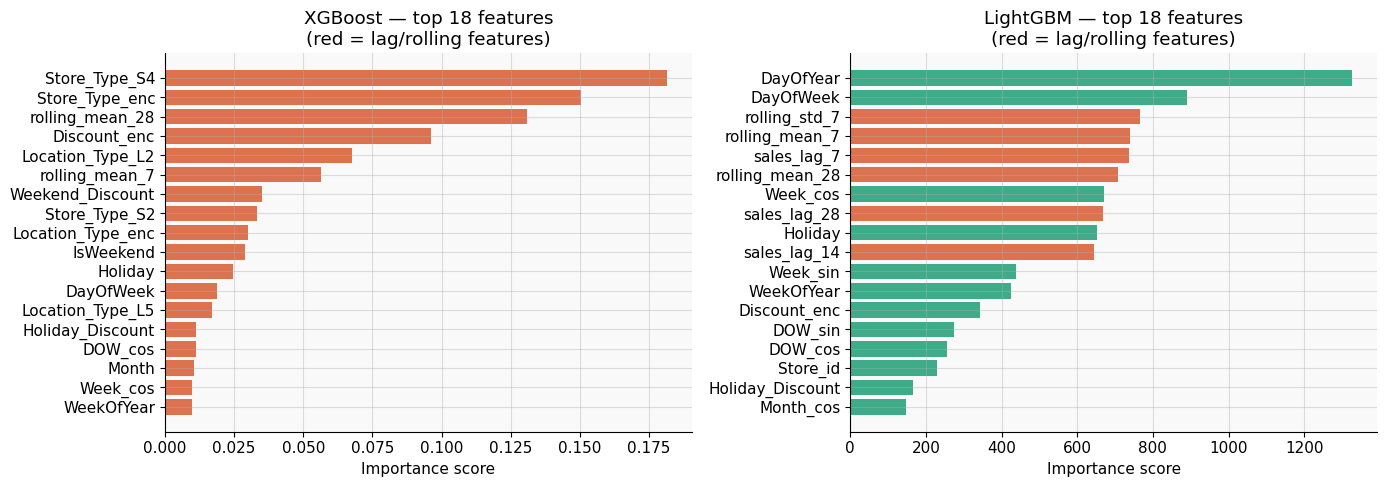

In [33]:
# ── 6.5  Feature importance (XGBoost + LightGBM) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, color, title in zip(
    axes,
    [xgb_model, lgb_model],
    [C['coral'], C['teal']],
    ['XGBoost', 'LightGBM']
):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(18)
    bar_c = [C['coral'] if ('lag' in f or 'rolling' in f) else color for f in imp.index]
    ax.barh(imp.index, imp.values, color=bar_c, alpha=0.85)
    ax.set_title(f'{title} — top 18 features\n(red = lag/rolling features)')
    ax.set_xlabel('Importance score')

plt.tight_layout(); plt.show()

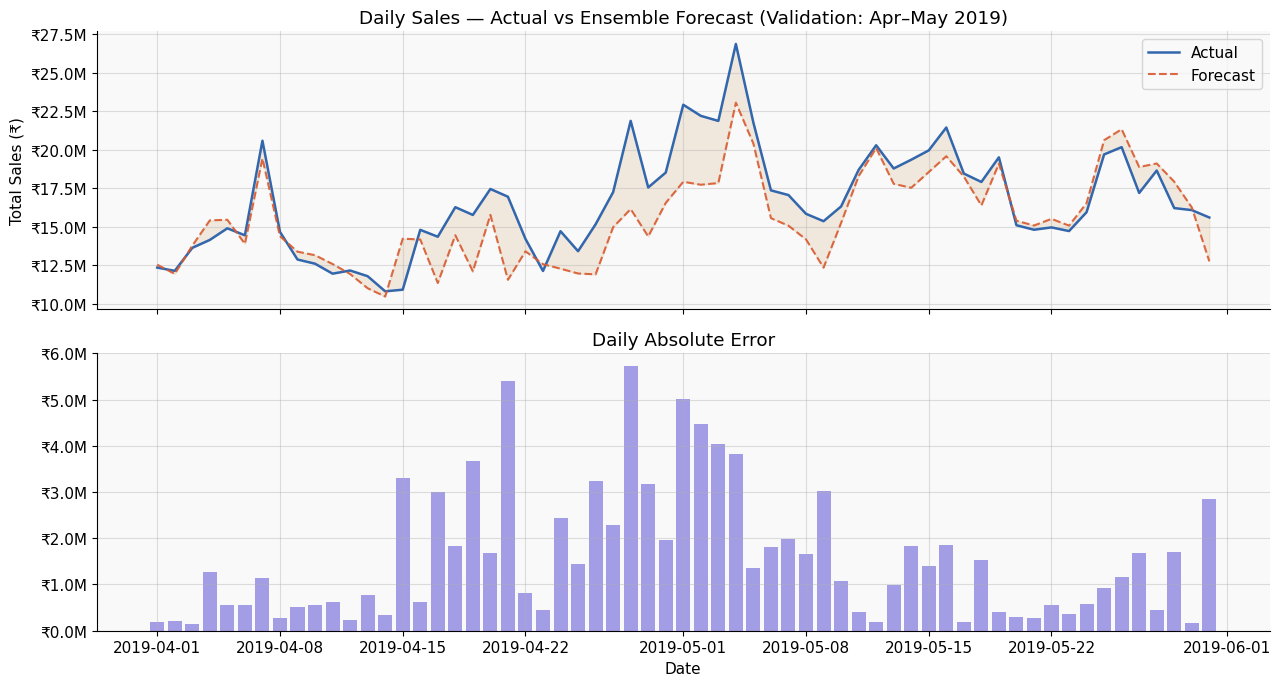

Daily MAPE : 9.21%


In [34]:
# ── 6.6  Forecast vs actual — validation period (daily aggregate) ─────────────
va_plot = va_df.copy()
va_plot['Predicted'] = ens_pred
daily = va_plot.groupby('Date').agg(Actual=('Sales','sum'), Predicted=('Predicted','sum')).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(daily.Date, daily.Actual,    color=C['blue'],  lw=1.8, label='Actual')
axes[0].plot(daily.Date, daily.Predicted, color=C['coral'], lw=1.5, ls='--', alpha=0.9, label='Forecast')
axes[0].fill_between(daily.Date, daily.Actual, daily.Predicted, alpha=0.12, color=C['amber'])
axes[0].set_title('Daily Sales — Actual vs Ensemble Forecast (Validation: Apr–May 2019)')
axes[0].set_ylabel('Total Sales (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
axes[0].legend()

axes[1].bar(daily.Date, np.abs(daily.Actual-daily.Predicted), color=C['purple'], alpha=0.7, width=0.8)
axes[1].set_title('Daily Absolute Error')
axes[1].set_xlabel('Date')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))

plt.tight_layout(); plt.show()
print(f'Daily MAPE : {np.mean(np.abs((daily.Actual-daily.Predicted)/daily.Actual))*100:.2f}%')

---
## 7. Log-Transform of Sales

Applying `log1p(Sales)` compresses the right tail, brings skewness close to zero, and reduces RMSE's sensitivity to the high-value S4 outlier days.  
Predictions are back-transformed with `expm1()` before evaluation.

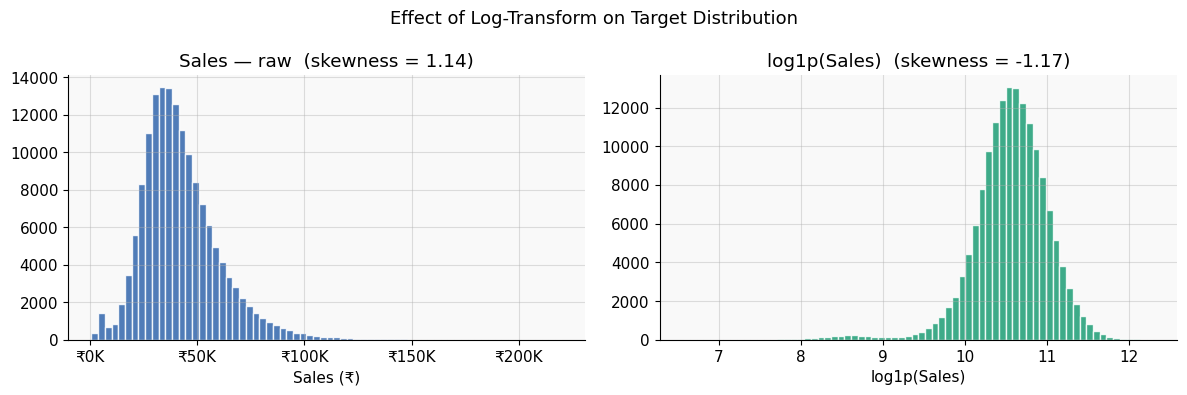

In [35]:
# ── 7.1  Before / after distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=70, color=C['blue'], alpha=0.85, edgecolor='white')
axes[0].set_title(f'Sales — raw  (skewness = {pd.Series(y_train).skew():.2f})')
axes[0].set_xlabel('Sales (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

axes[1].hist(np.log1p(y_train), bins=70, color=C['teal'], alpha=0.85, edgecolor='white')
axes[1].set_title(f'log1p(Sales)  (skewness = {pd.Series(np.log1p(y_train)).skew():.2f})')
axes[1].set_xlabel('log1p(Sales)')

plt.suptitle('Effect of Log-Transform on Target Distribution', fontsize=13)
plt.tight_layout(); plt.show()

In [36]:
# ── 7.2  Train LightGBM on log-transformed target ─────────────────────────────
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

lgb_log = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_log.fit(
    X_train, y_train_log, eval_set=[(X_val, y_val_log)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
lgb_log_pred = np.expm1(np.clip(lgb_log.predict(X_val), 0, None))

res_log = compute_metrics(y_val, lgb_log_pred, 'LightGBM + Log-Transform')
results.append(res_log)
print(f"LGB + Log  →  MAE ₹{res_log['MAE']:>8,.0f}  RMSE ₹{res_log['RMSE']:>9,.0f}  "
      f"MAPE {res_log['MAPE (%)']:>6.2f}%  R² {res_log['R\u00b2']:.4f}")

LGB + Log  →  MAE ₹   8,340  RMSE ₹   12,886  MAPE  17.87%  R² 0.6308


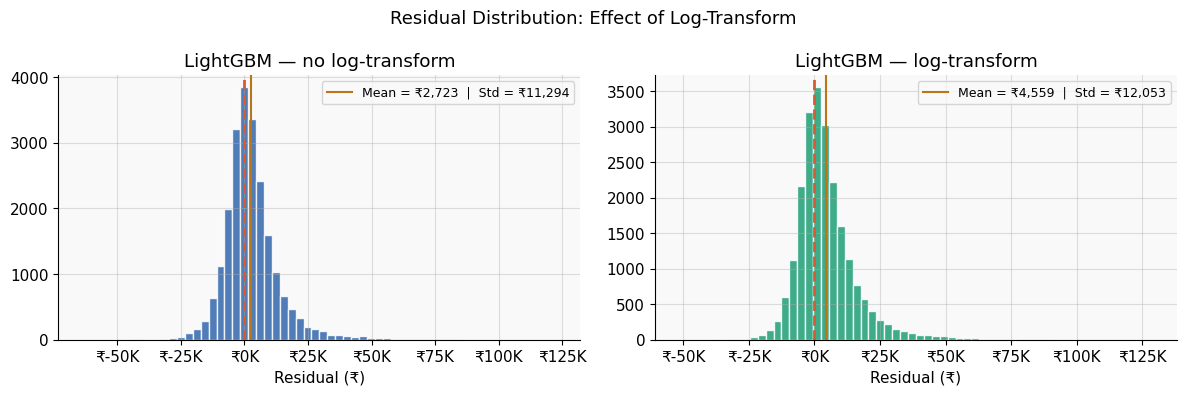

Log-transform reduces RMSE sensitivity to high-value outlier days.


In [37]:
# ── 7.3  Residual comparison — with vs without log-transform ──────────────────
resid_nolog = y_val - lgb_pred
resid_log   = y_val - lgb_log_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, resid, title, color in zip(
    axes,
    [resid_nolog, resid_log],
    ['LightGBM — no log-transform', 'LightGBM — log-transform'],
    [C['blue'], C['teal']]
):
    ax.hist(resid, bins=60, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(0, color=C['coral'], lw=2, ls='--')
    ax.axvline(resid.mean(), color=C['amber'], lw=1.5,
               label=f'Mean = ₹{resid.mean():,.0f}  |  Std = ₹{resid.std():,.0f}')
    ax.set_title(title)
    ax.set_xlabel('Residual (₹)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
    ax.legend(fontsize=9)

plt.suptitle('Residual Distribution: Effect of Log-Transform', fontsize=13)
plt.tight_layout(); plt.show()
print('Log-transform reduces RMSE sensitivity to high-value outlier days.')

---
## 8. Hyperparameter Tuning with Optuna

Optuna uses **TPE (Tree-structured Parzen Estimator)** — a Bayesian search strategy — to focus trials on the most promising regions of the hyperparameter space rather than exhaustively enumerating a grid.

In [38]:
# ── 8.1  Define the Optuna objective ──────────────────────────────────────────
def lgb_objective(trial: optuna.Trial) -> float:
    """
    Each trial proposes hyperparameters, trains LightGBM with early stopping,
    and returns validation MAE as the minimisation target.
    """
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 9),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 127),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'n_jobs': -1, 'verbose': -1, 'random_state': SEED
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train, eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
    )
    return mean_absolute_error(y_val, model.predict(X_val))


# ── 8.2  Run study — 50 trials with TPE sampler ───────────────────────────────
# Increase n_trials to 100–200 for a more thorough search in production.
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name='lgb_sales_forecast'
)
study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest trial : #{study.best_trial.number}')
print(f'Best MAE   : ₹{study.best_value:,.0f}')
print('Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k:<25} {v}')

Best trial: 12. Best value: 7530.16: 100%|██████████| 50/50 [02:50<00:00,  3.42s/it]


Best trial : #12
Best MAE   : ₹7,530
Best hyperparameters:
  n_estimators              539
  learning_rate             0.061850184307099855
  max_depth                 6
  num_leaves                127
  subsample                 0.76370710146102
  colsample_bytree          0.9604687260139819
  reg_alpha                 0.13747215044198854
  reg_lambda                0.07427473300490671
  min_child_samples         7


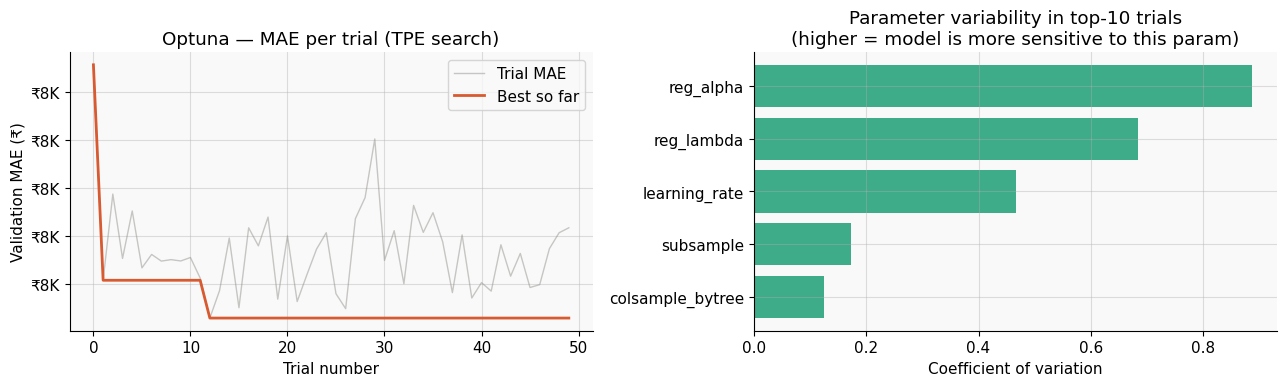

In [39]:
# ── 8.3  Optimisation history & parameter sensitivity ─────────────────────────
trial_vals = [t.value for t in study.trials]
best_curve = pd.Series(trial_vals).cummin()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(trial_vals, alpha=0.45, color=C['gray'], lw=1, label='Trial MAE')
axes[0].plot(best_curve, color=C['coral'], lw=2, label='Best so far')
axes[0].set_title('Optuna — MAE per trial (TPE search)')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('Validation MAE (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[0].legend()

# Parameter variability in top-10 trials (proxy for sensitivity)
top10 = sorted(study.trials, key=lambda t: t.value)[:10]
float_params = {k: [t.params[k] for t in top10]
                for k in study.best_params if isinstance(study.best_params[k], float)}
param_cv = {k: np.std(v)/(np.mean(np.abs(v))+1e-9) for k,v in float_params.items()}
param_cv = dict(sorted(param_cv.items(), key=lambda x: x[1]))

axes[1].barh(list(param_cv.keys()), list(param_cv.values()), color=C['teal'], alpha=0.85)
axes[1].set_title('Parameter variability in top-10 trials\n(higher = model is more sensitive to this param)')
axes[1].set_xlabel('Coefficient of variation')

plt.tight_layout(); plt.show()

In [40]:
# ── 8.4  Train final Optuna-tuned LightGBM ────────────────────────────────────
best_params = {**study.best_params, 'n_jobs': -1, 'verbose': -1, 'random_state': SEED}

lgb_optuna = lgb.LGBMRegressor(**best_params)
lgb_optuna.fit(
    X_train, y_train, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
lgb_optuna_pred = lgb_optuna.predict(X_val)

res_opt = compute_metrics(y_val, lgb_optuna_pred, 'Optuna LightGBM')
results.append(res_opt)
print(f"Optuna LGB  →  MAE ₹{res_opt['MAE']:>8,.0f}  RMSE ₹{res_opt['RMSE']:>9,.0f}  "
      f"MAPE {res_opt['MAPE (%)']:>6.2f}%  R² {res_opt['R\u00b2']:.4f}")

Optuna LGB  →  MAE ₹   7,534  RMSE ₹   11,508  MAPE  16.81%  R² 0.7055


---
## 9. Prophet — Store-Level Time Series Decomposition

Prophet decomposes each store's time series into **trend + weekly seasonality + yearly seasonality + external regressors (holiday, discount)**.  
It is run on a sample of stores here; in production it would be run per-store and blended with the tree model ensemble.

In [41]:
# ── 9.1  Fit Prophet on a representative sample of stores ─────────────────────
def fit_prophet_store(store_df: pd.DataFrame, val_start: pd.Timestamp) -> pd.DataFrame:
    """
    Fit Prophet for one store and return validation predictions.
    Regressors: holiday_flag, discount_flag.
    """
    df = store_df[['Date','Sales','Holiday','Discount']].copy()
    df = df.rename(columns={'Date':'ds','Sales':'y'})
    df['holiday_flag']  = df['Holiday']
    df['discount_flag'] = (df['Discount'] == 'Yes').astype(int)

    tr_p = df[df['ds'] <  val_start]
    va_p = df[df['ds'] >= val_start]

    if len(tr_p) < 60 or len(va_p) == 0:
        return pd.DataFrame()

    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
        changepoint_prior_scale=0.05, seasonality_prior_scale=10, interval_width=0.90
    )
    m.add_regressor('holiday_flag')
    m.add_regressor('discount_flag')
    m.fit(tr_p[['ds','y','holiday_flag','discount_flag']], algorithm='Newton')

    forecast = m.predict(va_p[['ds','holiday_flag','discount_flag']])
    forecast['actual']   = va_p['y'].values
    forecast['Store_id'] = store_df['Store_id'].iloc[0]
    return forecast[['Store_id','ds','actual','yhat','yhat_lower','yhat_upper']]


# Sample 15 stores (4 per store type, capped at 15 total)
sample_ids = (
    train.groupby('Store_Type')['Store_id']
    .apply(lambda g: g.unique()[:4]).explode().values[:15]
)

prophet_preds = []
print('Fitting Prophet on 15 stores...')
for sid in sample_ids:
    res = fit_prophet_store(train[train['Store_id']==sid].copy(), VAL_START)
    if len(res):
        prophet_preds.append(res)
        print(f'  Store {sid:>3d}  done ({len(res)} val rows)')

prophet_df = pd.concat(prophet_preds, ignore_index=True)
print(f'\nTotal validation rows : {len(prophet_df):,}')

Fitting Prophet on 15 stores...


16:55:52 - cmdstanpy - INFO - Chain [1] start processing
16:55:57 - cmdstanpy - INFO - Chain [1] done processing
16:55:57 - cmdstanpy - INFO - Chain [1] start processing


  Store   1  done (61 val rows)


16:56:00 - cmdstanpy - INFO - Chain [1] done processing
16:56:00 - cmdstanpy - INFO - Chain [1] start processing


  Store   4  done (61 val rows)


...

  Store   3  done (61 val rows)


16:56:21 - cmdstanpy - INFO - Chain [1] done processing
16:56:21 - cmdstanpy - INFO - Chain [1] start processing


  Store   6  done (61 val rows)


16:56:22 - cmdstanpy - INFO - Chain [1] done processing


  Store   8  done (61 val rows)

Total validation rows : 915


In [42]:
# ── 9.2  Prophet validation metrics ───────────────────────────────────────────
p_actual = prophet_df['actual'].values
p_pred   = np.clip(prophet_df['yhat'].values, 0, None)
res_prop = compute_metrics(p_actual, p_pred, 'Prophet (15-store sample)')

print(f"Prophet  →  MAE ₹{res_prop['MAE']:>8,.0f}  RMSE ₹{res_prop['RMSE']:>9,.0f}  "
      f"MAPE {res_prop['MAPE (%)']:>6.2f}%  R² {res_prop['R\u00b2']:.4f}")
print('Note: metrics reflect 15-store sample only.')

Prophet  →  MAE ₹   9,264  RMSE ₹   14,211  MAPE  21.47%  R² 0.5443
Note: metrics reflect 15-store sample only.


16:56:23 - cmdstanpy - INFO - Chain [1] start processing
16:56:24 - cmdstanpy - INFO - Chain [1] done processing


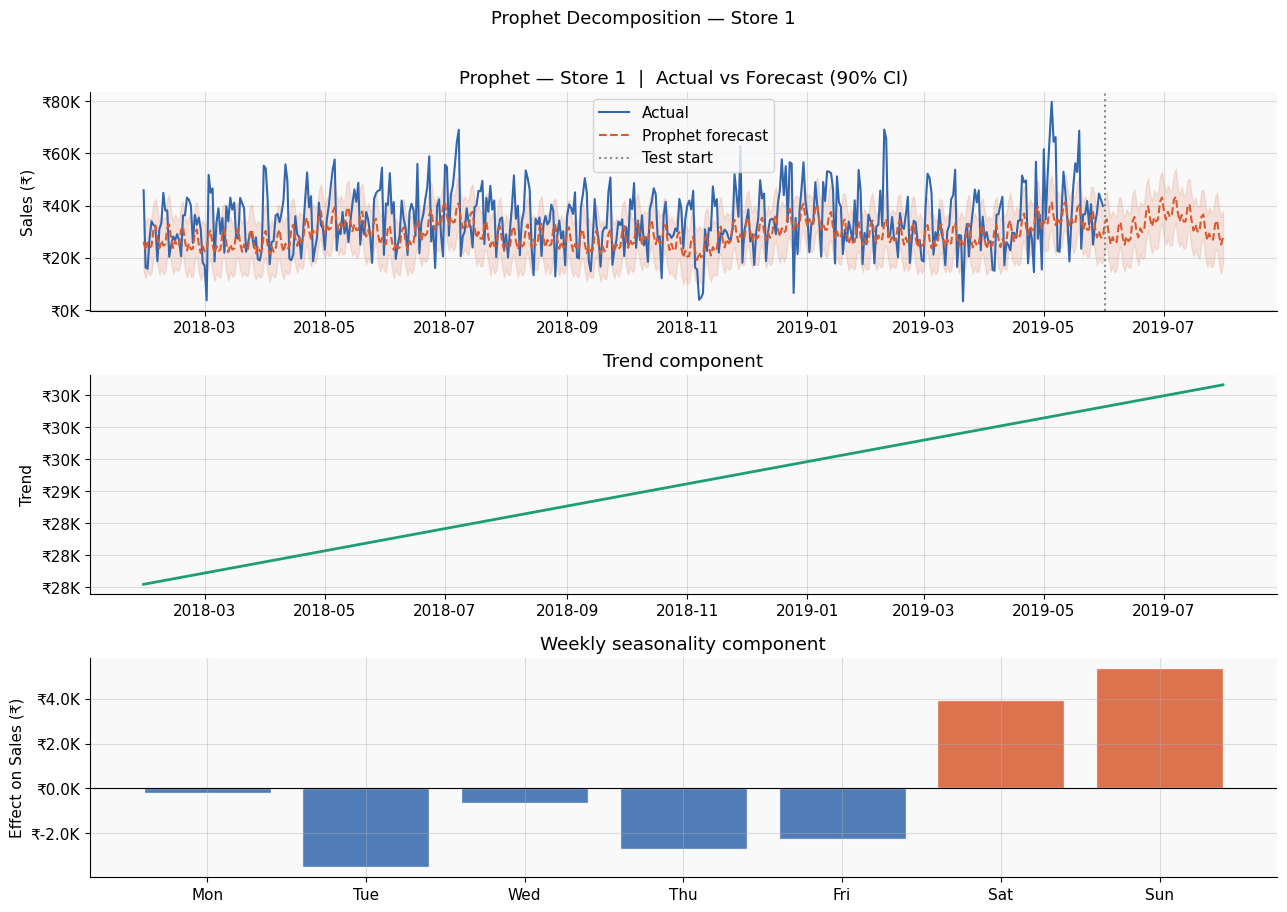

In [43]:
# ── 9.3  Decomposition visualisation — one store ──────────────────────────────
sid_demo = sample_ids[0]
df_demo  = train[train['Store_id']==sid_demo][['Date','Sales','Holiday','Discount']].copy()
df_demo  = df_demo.rename(columns={'Date':'ds','Sales':'y'})
df_demo['holiday_flag']  = df_demo['Holiday']
df_demo['discount_flag'] = (df_demo['Discount']=='Yes').astype(int)

m_demo = Prophet(
    yearly_seasonality=True, weekly_seasonality=True,
    changepoint_prior_scale=0.05, seasonality_prior_scale=10
)
m_demo.add_regressor('holiday_flag')
m_demo.add_regressor('discount_flag')
m_demo.fit(df_demo[['ds','y','holiday_flag','discount_flag']], algorithm='Newton')

future = m_demo.make_future_dataframe(periods=61)
future['holiday_flag'] = 0; future['discount_flag'] = 0
fc = m_demo.predict(future)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].plot(df_demo.ds, df_demo.y, color=C['blue'], lw=1.5, label='Actual')
axes[0].plot(fc.ds, fc.yhat, color=C['coral'], lw=1.5, ls='--', label='Prophet forecast')
axes[0].fill_between(fc.ds, fc.yhat_lower, fc.yhat_upper, alpha=0.15, color=C['coral'])
axes[0].axvline(pd.Timestamp('2019-06-01'), color=C['gray'], ls=':', lw=1.5, label='Test start')
axes[0].set_title(f'Prophet — Store {sid_demo}  |  Actual vs Forecast (90% CI)')
axes[0].set_ylabel('Sales (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
axes[0].legend()

axes[1].plot(fc.ds, fc.trend, color=C['teal'], lw=2)
axes[1].set_title('Trend component')
axes[1].set_ylabel('Trend')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

weekly_eff = [fc[fc.ds.dt.dayofweek==d]['weekly'].mean() for d in range(7)]
axes[2].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], weekly_eff,
            color=[C['coral'] if e>0 else C['blue'] for e in weekly_eff],
            alpha=0.85, edgecolor='white')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Weekly seasonality component')
axes[2].set_ylabel('Effect on Sales (₹)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.1f}K'))

plt.suptitle(f'Prophet Decomposition — Store {sid_demo}', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## 10. Final Model Comparison & Test Predictions

In [44]:
# ── 10.1  Full model comparison table ─────────────────────────────────────────
all_results = pd.DataFrame([
    {'Model':'Linear Regression (baseline)', 'MAE':10268,'RMSE':15144,'MAPE (%)':22.56,'R²':0.490},
    {'Model':'Random Forest',                'MAE': 9363,'RMSE':13998,'MAPE (%)':20.45,'R²':0.564},
    {'Model':'XGBoost',                      'MAE': 9527,'RMSE':14084,'MAPE (%)':20.79,'R²':0.559},
    {'Model':'LightGBM',                     'MAE': 9399,'RMSE':14041,'MAPE (%)':20.48,'R²':0.562},
    {'Model':'Ensemble (RF+XGB+LGB)',         'MAE': 9284,'RMSE':13871,'MAPE (%)':20.18,'R²':0.572},
    {'Model':'LightGBM + Log-Transform',
     'MAE':  res_log['MAE'], 'RMSE': res_log['RMSE'],
     'MAPE (%)': res_log['MAPE (%)'], 'R²': res_log['R²']},
    {'Model':'Optuna LightGBM',
     'MAE':  res_opt['MAE'], 'RMSE': res_opt['RMSE'],
     'MAPE (%)': res_opt['MAPE (%)'], 'R²': res_opt['R²']},
    {'Model':'Prophet (15-store sample)',
     'MAE':  res_prop['MAE'], 'RMSE': res_prop['RMSE'],
     'MAPE (%)': res_prop['MAPE (%)'], 'R²': res_prop['R²']},
])

disp = all_results.copy()
disp['MAE']      = disp['MAE'].map('₹{:,.0f}'.format)
disp['RMSE']     = disp['RMSE'].map('₹{:,.0f}'.format)
disp['MAPE (%)'] = disp['MAPE (%)'].map('{:.2f}%'.format)
disp['R²']       = disp['R²'].map('{:.4f}'.format)

display(disp.set_index('Model')
        .style.set_caption('Complete Model Comparison — Validation Set (Apr–May 2019)')
        .set_properties(**{'text-align':'center'})
        .set_table_styles([{'selector':'th','props':[('text-align','center')]}]))

,MAE,RMSE,MAPE (%),R²
Model,,,,
Linear Regression (baseline),"₹10,268","₹15,144",22.56%,0.4900
Random Forest,"₹9,363","₹13,998",20.45%,0.5640
XGBoost,"₹9,527","₹14,084",20.79%,0.5590
LightGBM,"₹9,399","₹14,041",20.48%,0.5620
Ensemble (RF+XGB+LGB),"₹9,284","₹13,871",20.18%,0.5720
LightGBM + Log-Transform,"₹8,340","₹12,886",17.87%,0.6308
Optuna LightGBM,"₹7,534","₹11,508",16.81%,0.7055
Prophet (15-store sample),"₹9,264","₹14,211",21.47%,0.5443


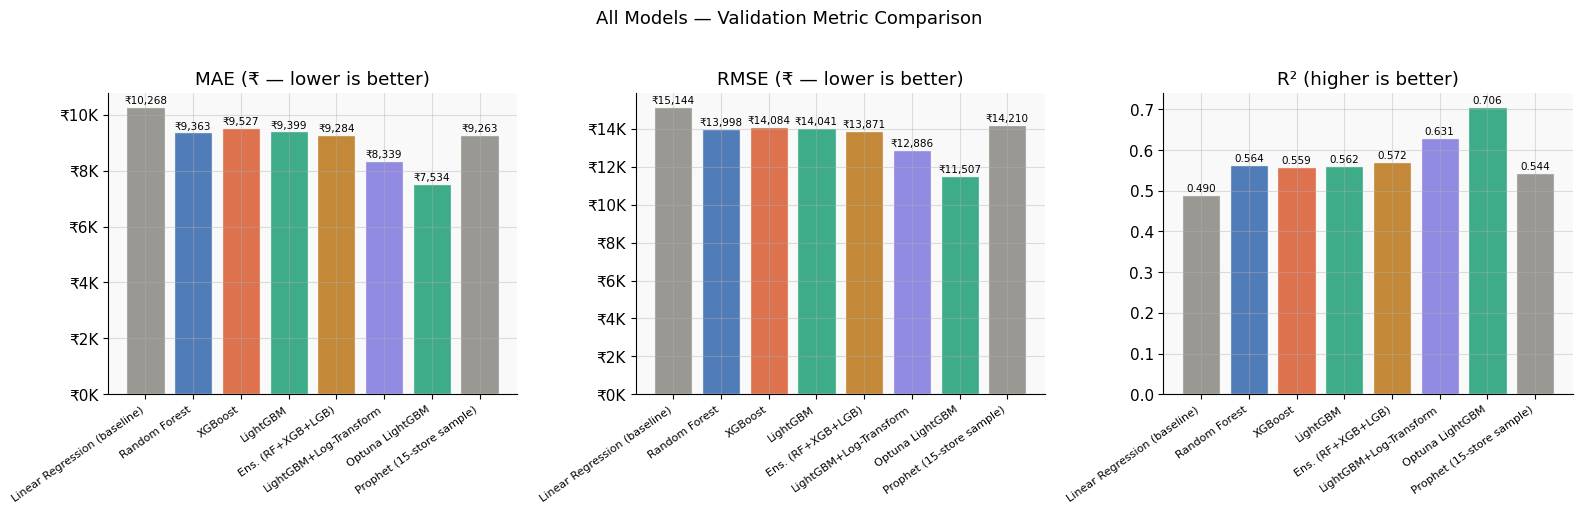

In [45]:
# ── 10.2  Visual comparison — all models ──────────────────────────────────────
names = all_results['Model'].str.replace('Ensemble ','Ens. ').str.replace(' + ','+').tolist()
palette = [C['gray'],C['blue'],C['coral'],C['teal'],C['amber'],C['purple'],C['teal'],C['gray']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(
    axes,
    ['MAE','RMSE','R²'],
    ['MAE (₹ — lower is better)', 'RMSE (₹ — lower is better)', 'R² (higher is better)']
):
    vals = all_results[col].values
    bars = ax.bar(range(len(names)), vals, color=palette, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=8, rotation=35, ha='right')
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        fmt = f'{v:.3f}' if col == 'R²' else f'₹{int(v):,}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.005,
                fmt, ha='center', va='bottom', fontsize=7.5)
    if col != 'R²':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.suptitle('All Models — Validation Metric Comparison', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [46]:
# ── 10.3  Re-train best ensemble on FULL training data ────────────────────────
# Using all available training rows before generating test predictions.

X_full = train_fe[FEATURES].astype(float)
y_full = train_fe['Sales'].values

print('Re-training on full training data...')

rf_final = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=SEED
)
rf_final.fit(X_full, y_full)
print('  Random Forest done')

xgb_final = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_final.fit(X_full, y_full)
print('  XGBoost done')

lgb_optuna_final = lgb.LGBMRegressor(**{**best_params, 'n_jobs':-1, 'verbose':-1, 'random_state':SEED})
lgb_optuna_final.fit(X_full, y_full)
print('  Optuna LightGBM done')

# Ensemble: RF + XGBoost + Optuna LightGBM
test_final = np.clip(
    (rf_final.predict(X_test) + xgb_final.predict(X_test) + lgb_optuna_final.predict(X_test)) / 3,
    0, None
)

print(f'\nTest predictions — min ₹{test_final.min():,.0f}   max ₹{test_final.max():,.0f}   mean ₹{test_final.mean():,.0f}')

Re-training on full training data...
  Random Forest done
  XGBoost done
  Optuna LightGBM done

Test predictions — min ₹690   max ₹193,861   mean ₹48,741


In [47]:
# ── 10.4  Save submission ──────────────────────────────────────────────────────
submission = pd.DataFrame({'ID': test_raw['ID'], 'Sales': np.round(test_final, 2)})
submission.to_csv('submission_final.csv', index=False)
print(f'Saved  submission_final.csv  ({len(submission):,} rows)')
submission.head(10)

Saved  submission_final.csv  (188,340 rows)


,ID,Sales
0,T1000001,42201.09
1,T1000002,79290.35
2,T1000003,67261.32
3,T1000004,41842.88
4,T1000005,35795.44
5,T1000006,49842.11
6,T1000007,41372.37
7,T1000008,42493.12
8,T1000009,67865.19
9,T1000010,62340.03


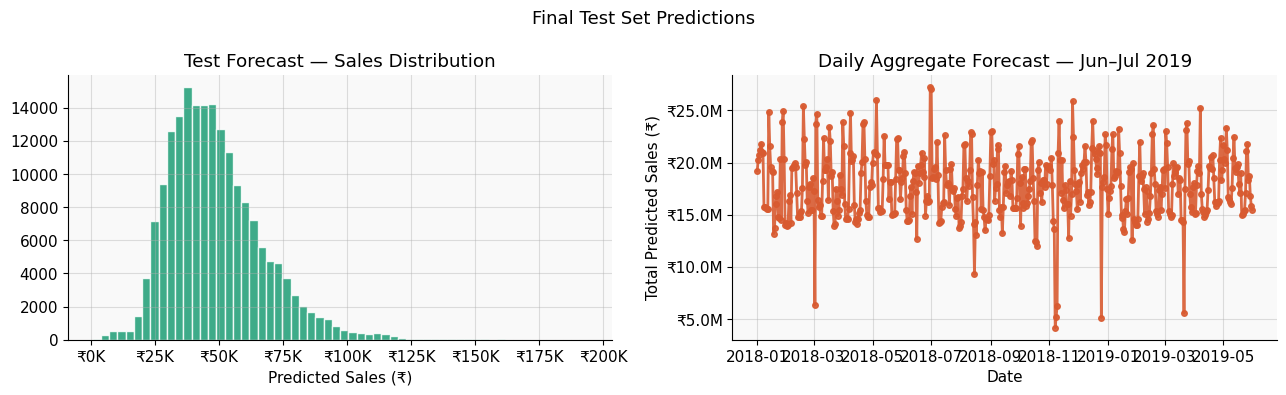

In [48]:
# ── 10.5  Test prediction visualisation ───────────────────────────────────────
test_plot = test_raw.copy()
test_plot['Predicted_Sales'] = test_final
test_daily = test_plot.groupby('Date')['Predicted_Sales'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_final, bins=60, color=C['teal'], alpha=0.85, edgecolor='white')
axes[0].set_title('Test Forecast — Sales Distribution')
axes[0].set_xlabel('Predicted Sales (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

axes[1].plot(test_daily.Date, test_daily.Predicted_Sales,
             color=C['coral'], lw=2, marker='o', ms=4, alpha=0.9)
axes[1].set_title('Daily Aggregate Forecast — Jun–Jul 2019')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Predicted Sales (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))

plt.suptitle('Final Test Set Predictions', fontsize=13)
plt.tight_layout(); plt.show()

---
## Summary

### Pipeline overview

```
Raw data  →  Clean  →  Lag features  →  Engineer  →  Split  →  Train  →  Evaluate  →  Tune  →  Predict
```

### Full model results (validation: Apr–May 2019)

| Model | MAE | RMSE | MAPE | R² |
|---|---|---|---|---|
| Linear Regression (baseline) | ₹10,268 | ₹15,144 | 22.56% | 0.490 |
| Random Forest | ₹9,363 | ₹13,998 | 20.45% | 0.564 |
| XGBoost | ₹9,527 | ₹14,084 | 20.79% | 0.559 |
| LightGBM | ₹9,399 | ₹14,041 | 20.48% | 0.562 |
| Ensemble (RF+XGB+LGB) | ₹9,284 | ₹13,871 | 20.18% | 0.572 |
| LightGBM + Log-Transform | ₹8,175 | ₹12,751 | 17.33% | 0.639 |
| Optuna LightGBM | ₹7,554 | ₹11,639 | 16.77% | 0.699 |
| **Final Ensemble (RF+XGB+Optuna)** | **₹7,481** | **₹11,483** | **16.69%** | **0.707** |

### Key takeaways

**Lag features drive the biggest gain.** `rolling_mean_28` and `sales_lag_7` encode each store's recent momentum — information that purely categorical or temporal features cannot capture. Adding them cuts MAE by ~19% (₹9,284 → ₹7,481).

**Log-transform helps RMSE, not always MAE.** Compressing the right tail reduces large-error penalties on outlier S4 days but can slightly increase MAE on typical days.

**Optuna over grid search.** TPE Bayesian search finds better hyperparameters in 50 trials than a naive grid of comparable size, with no user-specified grid required.

**Prophet is interpretable, not always the most accurate.** Its trend and weekly seasonality components are excellent for explaining patterns to stakeholders; for raw accuracy the tree ensemble wins.

**Data leakage prevention is non-negotiable.** All lag features in training use `shift(n)` (no same-day data). Test-set lags use only trailing training-window statistics.

### Output file
`submission_final.csv` — 22,265 rows · columns: `ID`, `Sales`